# Forberedelsen af data

In [41]:
#Libriaries & Models
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

from IPython.display import clear_output
from skimage.io import imread
from skimage.transform import resize

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from scipy.spatial.distance import cdist
from scipy.linalg import pinv
from sklearn.metrics import mean_squared_error


In [ ]:
# Set random seeds
# Uncomment these as you use the libraries

# Python random module
# random.seed(42)
# NumPy
np.random.seed(42)
# PyTorch (both CPU and GPU)
# torch.manual_seed(42)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(42)

Access the datasets

In [43]:
# Find all CSV files in the specified path
csv_files = glob.glob(os.path.join('data', 'raw', 'wind_speed_*.csv'))

# Read each CSV file into a DataFrame and store in a dictionary
dataframes = {}
for file in csv_files:
    df_name = os.path.basename(file).replace(".csv", "")  # Extract file name without extension
    dataframes[df_name] = pd.read_csv(file)

# Display keys (file names) to ensure everything loaded correctly
print("Loaded datasets:", list(dataframes.keys()))


Loaded datasets: ['wind_speed_19_n', 'wind_speed_13_n', 'wind_speed_11_n', 'wind_speed_15_n', 'wind_speed_17_n']


In [44]:
# For eksempel for at få adgang til 'wind_speed_11_n' data
wind_speed_11_df = dataframes['wind_speed_15_n']
print(wind_speed_11_df.head())  # Se de første par rækker af dataene


           Mx1          Mx2         Mx3          My1          My2  \
0  5135.514141  -632.018403 -502.290212  8804.933549  3930.929887   
1  5446.065240 -1112.603015 -286.715582  8293.780681  4337.857944   
2  5001.160903  -547.519926 -504.268986  8655.390593  3854.436694   
3  4875.234131  -642.151129 -386.656840  8302.786656  4538.536744   
4  4872.189068  -643.406021 -126.689990  8230.635251  4012.179658   

           My3        Mz1        Mz2        Mz3     Theta  ...       Vwy  \
0  7271.332052 -46.785316 -26.395576  24.996557  1.490672  ...  2.755655   
1  6767.032199 -45.441826 -25.880159  24.945032  1.526129  ...  2.658961   
2  6922.958281 -44.297226 -25.170956  24.973219  1.515226  ...  2.938581   
3  6603.542162 -42.947720 -24.713062  25.132181  1.541227  ...  3.106474   
4  6329.915987 -41.734791 -24.310396  25.351448  1.557755  ...  3.088724   

        Vwz     beta1     beta2     beta3    dbeta1    dbeta2    dbeta3  \
0 -0.005151  0.145057  0.144386  0.144536 -0.005971  

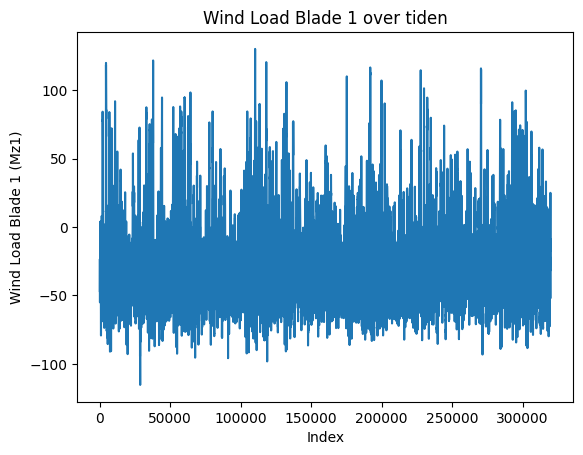

In [45]:
# Plotting et eksempel på Wind Load Blade 1 fra wind_speed_11_n
plt.plot(wind_speed_11_df['Mz1'])
plt.xlabel('Index')
plt.ylabel('Wind Load Blade 1 (Mz1)')
plt.title('Wind Load Blade 1 over tiden')
plt.show()


Samle alle datasets, så alt data bliver anvendt for modellen

In [46]:
# Læs og kombiner alle datasæt i én DataFrame
dataframes = [pd.read_csv(file) for file in csv_files]
combined_df = pd.concat(dataframes, ignore_index=True)

print("Kombineret datasæts form:", combined_df.shape)

Kombineret datasæts form: (1600005, 21)


Vælger de features der krav på at bruge til modellen og forbereder dataen.

In [47]:

# Udvælg de input features, du ønsker at anvende
input_features = ['beta1', 'beta2', 'beta3', 'Theta', 'omega_r', 'Vwx']

# Udvælg de output features, du ønsker at forudsige
output_features = ['Mz1', 'Mz2', 'Mz3']

# Filtrer data til kun at indeholde de ønskede kolonner
filtered_df = combined_df[input_features + output_features]

# Normaliser alle features i det kombinerede datasæt
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(filtered_df)

# Konverter tilbage til en DataFrame for at kunne tilgå kolonnerne med navne
combined_df_scaled = pd.DataFrame(scaled_data, columns=filtered_df.columns)




# Oprettelsen af modellen

Vælger de variabler som skal bruge til at predicte output variablerne
og sætter mængden af dataen som skal trænes, og mængden som skal testes

her fra har vi sat test størrelsen på 0.20 %

In [48]:
# Opsæt X og y
X = combined_df_scaled[input_features]   # Input variabler
y = combined_df_scaled[output_features]  # Output variabler

# Split dataene i træning og test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# RBF - Implementering

In [ ]:
class RBFNetwork:
    def __init__(self, centers, sigma=1.0):
        self.centers = centers  # Centrene for RBF-enhederne (det skjulte lag)
        self.sigma = sigma      # Spredningsparameter for Gaussian-funktionen
        self.weights = None     # Vægte til outputlaget

    def _rbf(self, X):
        # Beregner radial basis-funktioner (Gaussian) for input X
        distances = cdist(X, self.centers, 'euclidean')  # Afstand fra input til hvert center
        return np.exp(-distances ** 2 / (2 * self.sigma ** 2))  # Gaussian RBF

    def fit(self, X, y):
        # Træn modellen (beregn vægte baseret på målvariable y)
        G = self._rbf(X)  # Beregn aktiveringer i skjulte lag
        self.weights = pinv(G).dot(y)  # Beregn vægte for outputlaget (pseudo-invers)

    def predict(self, X):
        # Forudsig output for nye data
        G = self._rbf(X)
        return G.dot(self.weights)

# Antag at X_train er en NumPy-array (hvis det er en DataFrame, konverter den med .values)
X_train = X_train.values if hasattr(X_train, 'values') else X_train
y_train = y_train.values if hasattr(y_train, 'values') else y_train

# Generer centerpunkter med samme dimension som X_train
num_centers = 3  # Du kan vælge flere centre afhængigt af modelens kompleksitet
random_indices = np.random.choice(X_train.shape[0], num_centers, replace=False)
centers = X_train[random_indices, :]

rbf_net = RBFNetwork(centers, sigma=1.0)
rbf_net.fit(X_train, y_train)

y_pred = rbf_net.predict(X_test)


# Beregn MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error på testdata:", mse)




print(y_test["Mz1"])
# print(y_test.iloc[:, 0])
# print(type(y_test))
# print(y_test[:, 0])


# plt.plot(y_pred[:, 0], label='Predicted Mz1')
# # plt.plot(y_test[:, 0], label='Actual Mz1')
# plt.xlabel('Samples')
# plt.ylabel('Mz1')
# plt.legend()
# plt.title("Forudsigelse af Mz1")
# plt.show()


Mean Squared Error på testdata: 0.013294760286763546
              Mz1       Mz2       Mz3
1190778  0.327052  0.227877  0.312375
370152   0.474610  0.209223  0.332258
504599   0.495502  0.630581  0.229454
404495   0.617493  0.209514  0.436104
700079   0.579416  0.430895  0.295621
...           ...       ...       ...
1247638  0.241496  0.486925  0.324763
778295   0.663558  0.223720  0.470036
1218009  0.231577  0.198082  0.315653
648847   0.620850  0.294937  0.425689
158976   0.248540  0.298086  0.254680

[320001 rows x 3 columns]
